<a href="https://colab.research.google.com/github/TomaszPasnikowski/ML_2026_homeworks/blob/main/LAB5_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC


Let's redo the essential computations from the classes:

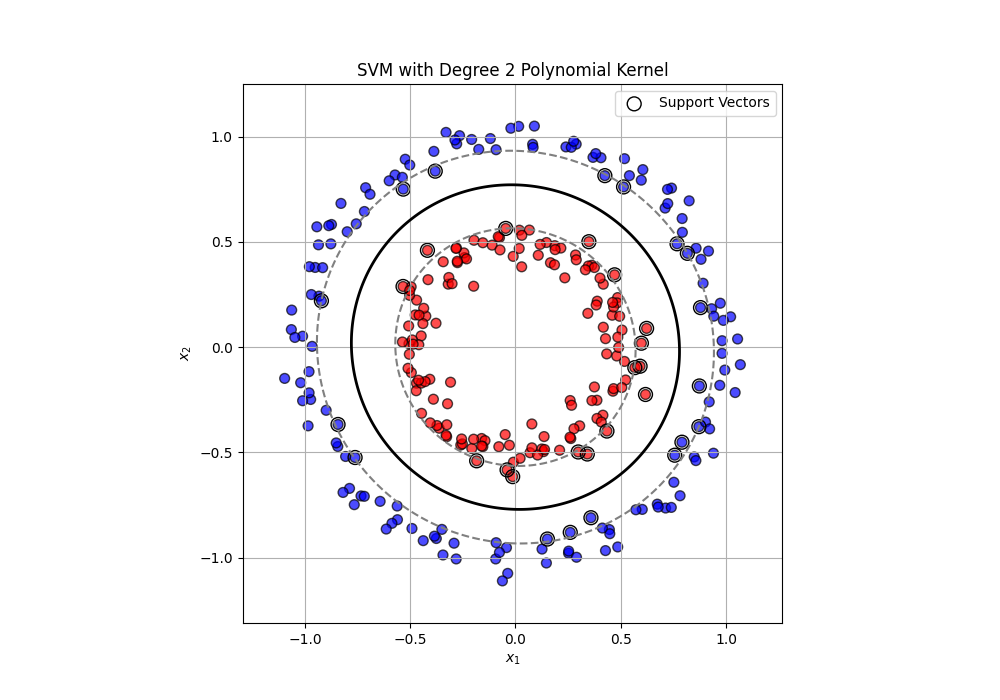

In [15]:
np.random.seed(42)
X, y = make_circles(n_samples=300, factor=0.5, noise=0.05)
clf = SVC(kernel='poly', degree=2, C=1.0, coef0=0, gamma=1.0)
clf.fit(X, y)

# 3. Create Meshgrid for Plotting Decision Boundary
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Flatten and Stack Grid for Prediction
grid = np.c_[xx.ravel(), yy.ravel()]
decision = clf.decision_function(grid)
decision = decision.reshape(xx.shape)

# 4. Plot Data Points and Decision Boundary
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7)

# Plot Decision Boundary and Margins
plt.contour(xx, yy, decision, levels=[0], linewidths=2, colors='k')
plt.contour(xx, yy, decision, levels=[-1, 1], linestyles='--', colors='grey')

# Highlight Support Vectors
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=100, linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')

plt.title('SVM with Degree 2 Polynomial Kernel')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True)

plt.gca().set_aspect('equal')  #  making the plot square
plt.show()


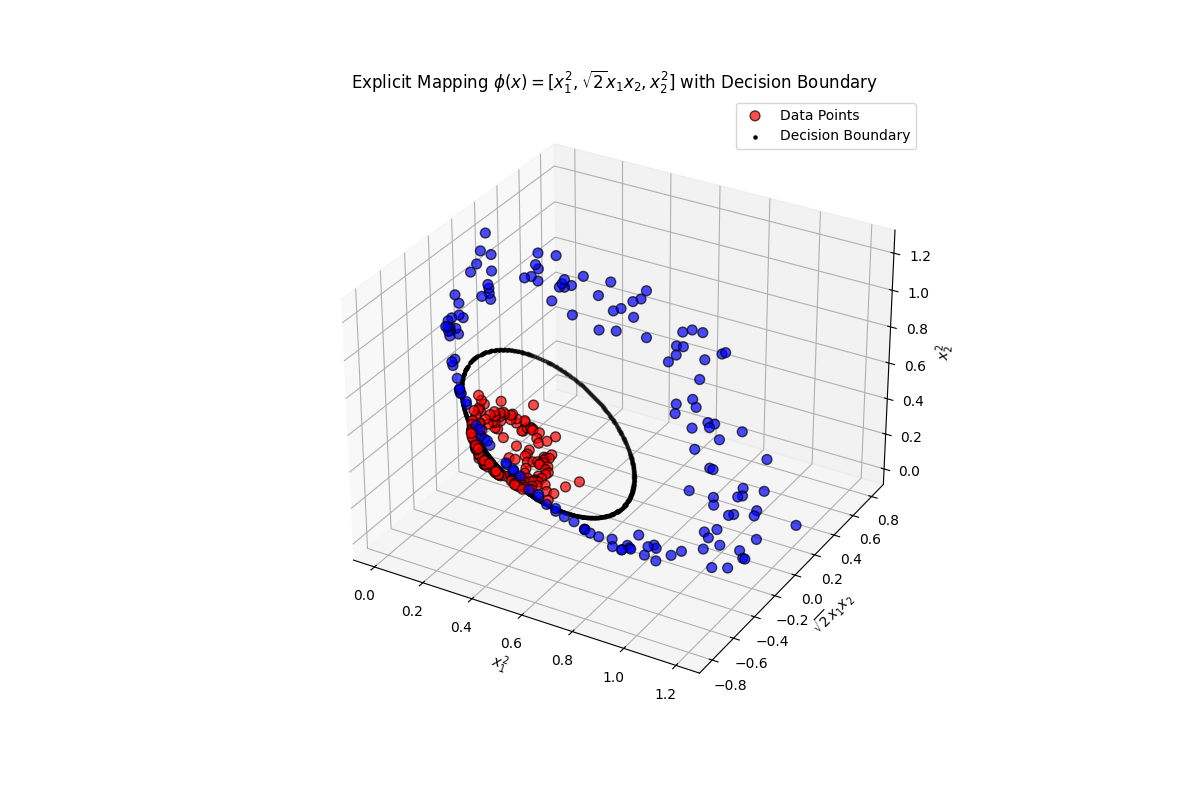

In [16]:
# 3D Plot for phi(x) with Decision Boundary
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 5. Visualize Explicit Mapping phi(x) = [x1^2, sqrt(2) x1 x2, x2^2]

# Apply phi(x) to each point
phi_X = np.array([[x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2] for x in X])

# Apply phi(x) to the meshgrid for decision boundary
phi_grid = np.array([[x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2] for x in grid])

# Scatter plot of transformed data
ax.scatter(phi_X[:, 0], phi_X[:, 1], phi_X[:, 2], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7, label='Data Points')

# Plot only the decision boundary contour (i.e. where decision == 0)
grid_decision = clf.decision_function(grid)
contour_mask = np.isclose(grid_decision, 0, atol=0.01)  # select points near decision boundary
ax.scatter(phi_grid[contour_mask, 0], phi_grid[contour_mask, 1], phi_grid[contour_mask, 2],
           c='k', s=5, label='Decision Boundary')

# Set axis labels and title for 3D plot
ax.set_title(r'Explicit Mapping $\phi(x) = [x_1^2, \sqrt{2} x_1 x_2, x_2^2]$ with Decision Boundary')
ax.set_xlabel(r'$x_1^2$')
ax.set_ylabel(r'$\sqrt{2} x_1 x_2$')
ax.set_zlabel(r'$x_2^2$')

# Add legend and grid
ax.legend()
ax.grid(True)

plt.show()


Now that we've performed a $2nd$-degree polynomial $SVC$ on $2-dim$ data and visualized the results in a $3-dim$ space, let's proceed in the inverse order. We know that: $$\phi(x_1, x_2) = (x_1^2, \hspace{0.1cm} \sqrt2x_1x_2, \hspace{0.1cm} x_2^2)$$
We can transform the initial data through this function and perform $SVC$ on $\phi(X)$ using a linear kernel.

In [17]:
phi_X = np.array([[x[0]**2, np.sqrt(2)*x[0]*x[1], x[1]**2] for x in X])
clf_3d = SVC(kernel='linear', C=1.0)
clf_3d.fit(phi_X, y)

SVC(kernel='linear')

Let's visualize the decision boundary with a meshgrid in $\mathbb{R}^3$.

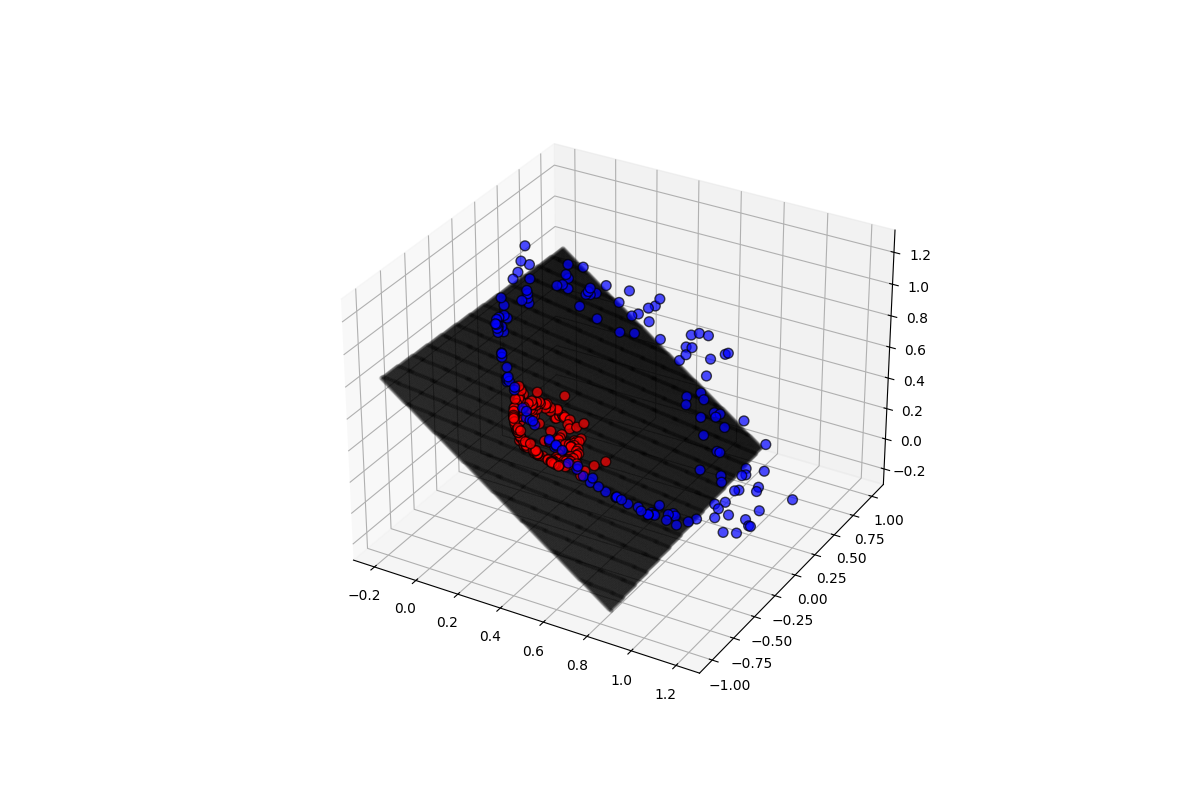

In [18]:
# 3. Create Meshgrid for Plotting Decision Boundary
x1_min, x1_max = phi_X[:, 0].min() - 0.2, phi_X[:, 0].max() + 0.2
x2_min, x2_max = phi_X[:, 1].min() - 0.2, phi_X[:, 1].max() + 0.2
x3_min, x3_max = phi_X[:, 2].min() - 0.2, phi_X[:, 2].max() + 0.2

x1, x2, x3 = np.meshgrid(np.linspace(x1_min, x1_max, 300),
                         np.linspace(x2_min, x2_max, 300),
                         np.linspace(x3_min, x3_max, 300))

grid_3d = np.c_[x1.ravel(), x2.ravel(), x3.ravel()]
grid_decision_3d = clf_3d.decision_function(grid_3d)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(phi_X[:, 0], phi_X[:, 1], phi_X[:, 2], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7, label='Data Points')

contour_mask_3d = np.isclose(grid_decision_3d, 0, atol=0.01)  # select points near decision boundary
ax.scatter(grid_3d[contour_mask_3d, 0], grid_3d[contour_mask_3d, 1], grid_3d[contour_mask_3d, 2],
           c='k', s=5, label='Decision Boundary', alpha= 0.1)
ax.view_init(elev=30, azim=-60)
plt.show()


Now the decision boundary is a plane as expected.

To investigate the difference of these two approaches let's investigate the preimage (with respect to function $\phi$)of the obtained plane.
$$\phi: \mathbb{R}^2 \to \mathbb{R}^3$$
$$\phi(x_1, x_2) = (x_1^2, \hspace{0.1cm} \sqrt2x_1x_2, \hspace{0.1cm} x_2^2)$$

Given a point $(a,b,c) \in \mathbb{R}^3$ contained in the separating plane, its preimage is:

$$
\begin{cases}
\{(\sqrt{a}, \frac{b}{\sqrt{2a}}), (-\sqrt{a}, \frac{b}{\sqrt{2a}})\} \hspace{0.2cm} \text{ if } a > 0,c > 0, b^2 = 2ac,\\
\{(0, \sqrt{c}), (0, -\sqrt{c})\} \hspace{0.2cm}  \text{  if } a = 0,b=0, c>0,\\
\{(\sqrt{a}, 0), (\sqrt{a}, 0)\} \hspace{0.2cm} \text{  if } a > 0,b=0, c=0,\\
\emptyset \hspace{0.2cm}  \text{ otherwise}
\end{cases}
$$

As we can see, a preimage exists only for points that meet certain conditions, therefore some points in the plane are impossible to obtain by the $\phi$ function. As shown below, the image $\phi(\mathbb{R}^2)$ is a plane embedded in $\mathbb{R}^3$ and it does not fill the whole space. Thus we can visualize the circle obtained in the first part as an intersection of the theoretical separating plane with $\phi(\mathbb{R}^2)$. We can mathematically percieve that boundary to be a plane but we will not see it through a $2-dim$ meshgrid and it will not matter when classyfing data because all the projected points will be contained in a cone embedded in $\mathbb{R}^3$, so a circle will be enough to separate them.

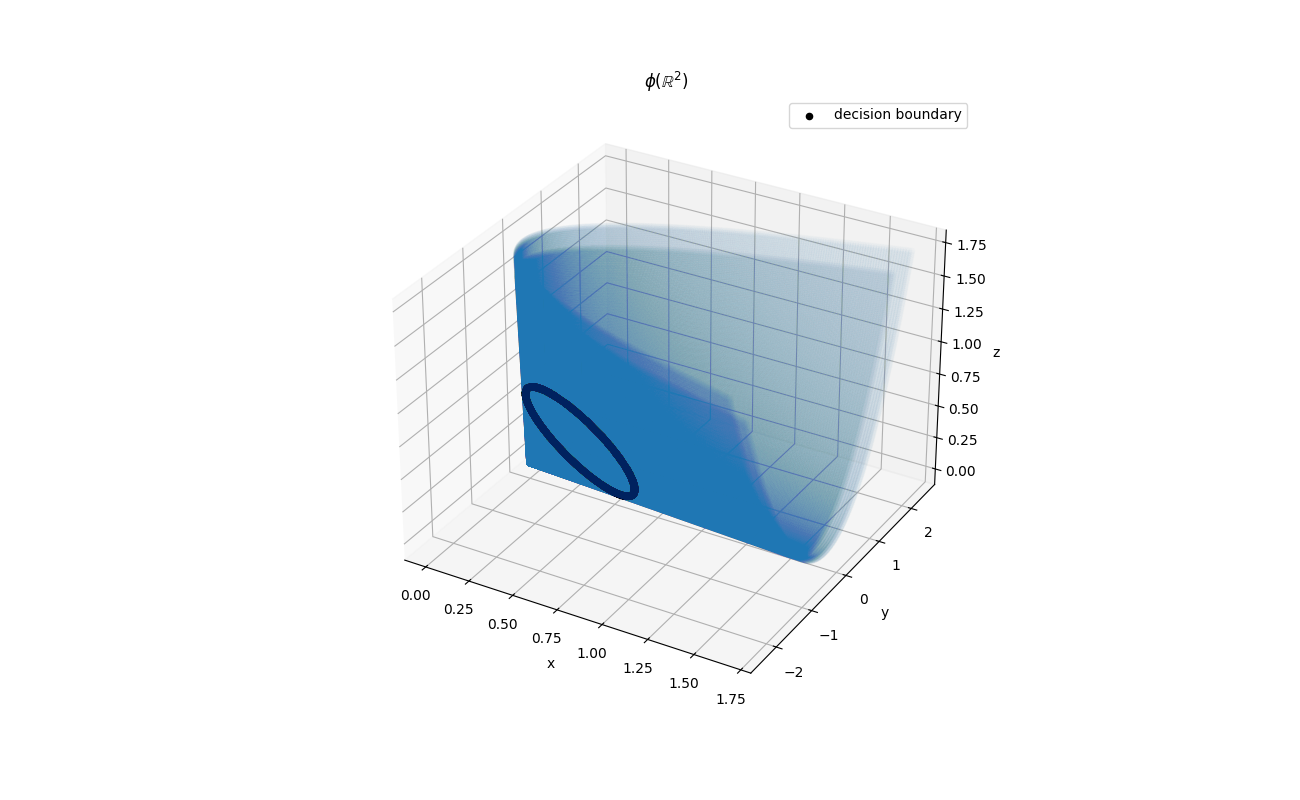

In [19]:
fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(phi_grid[~contour_mask][:,0], phi_grid[~contour_mask][:,1], phi_grid[~contour_mask][:,2], alpha= 0.01)
ax.scatter(phi_grid[contour_mask][:,0], phi_grid[contour_mask][:,1], phi_grid[contour_mask][:,2], alpha= 1, color= "black", label= "decision boundary")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(r"$\phi(\mathbb{R}^2)$")
ax.legend()
plt.show()

**Why** and **how** a hyperplane in 3D becomes a **circular (or elliptical) curve** when viewed back in the original 2D plane of the dataset?

A plane in $\mathbb{R}^3$ is defined by equation:
$$w_1\cdot a + w_2\cdot b + w_3\cdot c + w_4 = 0$$
For $(a,b,c)\in \mathbb{R}^3$. Substituting $(a,b,c) = \phi(x, y) = (x^2, \sqrt{2}xy, y^2)$ we get:
$$w_1 \cdot x^2 + (\sqrt{2}w_2)\cdot xy  + w_3\cdot y^2 + w_4 = 0$$
Which is a quadratic equation of $x$ and $y$, and usually results in a circullar or eliptical curve.

# Appendix: Interactive plots

In [ ]:
!pip install ipympl
%matplotlib widget
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(phi_X[:, 0], phi_X[:, 1], phi_X[:, 2], c=y, cmap='bwr', edgecolors='k', s=50, alpha=0.7, label='Data Points')

contour_mask_3d = np.isclose(grid_decision_3d, 0, atol=0.01)  # select points near decision boundary
ax.scatter(grid_3d[contour_mask_3d, 0], grid_3d[contour_mask_3d, 1], grid_3d[contour_mask_3d, 2],
           c='k', s=5, label='Decision Boundary', alpha= 0.1)
ax.view_init(elev=30, azim=-60)
plt.show()

In [ ]:
fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(phi_grid[~contour_mask][:,0], phi_grid[~contour_mask][:,1], phi_grid[~contour_mask][:,2], alpha= 0.01)
ax.scatter(phi_grid[contour_mask][:,0], phi_grid[contour_mask][:,1], phi_grid[contour_mask][:,2], alpha= 1, color= "black", label= "decision boundary")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("$\phi(\mathbb{R}^2)$")
ax.legend()
plt.show()